# Combine Air and Population Data
Merge Housing Unit Allocation Population data with the Air Team HAP data.


## Description of Program
- program:    ip1_2cv2_popair_2026-02-27
- task:       Spatially join population data with air team data
- Version:    2026-02-27
- project:    Southeast Texas Urban Integrated Field Lab
- funding:	  DOE
- author:     Nathanael Rosenheim

## Step 0: Good Housekeeping

In [1]:
# 1. Import all packages
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd  # For working with geospatial data
import os                # For file path management
import matplotlib.pyplot as plt # For plotting
import contextily as ctx # For adding basemaps

# load the common functions for this project
from ip1_1av1_common import *

In [2]:
# 2. Check versions
import sys
print("Python Version     ", sys.version)
print("pandas version: ", pd.__version__)

Python Version      3.13.9 | packaged by conda-forge | (main, Oct 22 2025, 23:12:41) [MSC v.1944 64 bit (AMD64)]
pandas version:  2.3.3


In [3]:
# 3. Check working directory
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\integrate_people_theme1_cookbook'

In [4]:
#4. Store Program Name for output files to have the same name
programname = "ip1_2cv2_popair"
# Make directory to save output
if not os.path.exists(programname):
    os.mkdir(programname)

# Step 1: Obtain Data

Rosenheim, N. (2022). Detailed Household and Housing Unit Characteristics: Data and Replication Code (Version 2) [Data set]. https://doi.org/10.17603/ds2-jwf6-s535

Rosenheim, N. (2025). Housing Unit Allocation SETX-UIFL. https://ckan.tacc.utexas.edu/dataset/housing-unit-allocation-setx-uifl

Rosenheim, N., Guidotti, R., Gardoni, P., & Peacock, W. G. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. Sustainable and Resilient Infrastructure, 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821 

In [5]:
# housing unit allocation data from CKAN
data_title = "2020 Housing Unit Allocation for SETX"
url = "https://ckan.tacc.utexas.edu/dataset/62308724-7eac-45ed-aeab-d4d6a46128e1/resource/5154eb5e-d8ff-4183-b361-fd530513e3c1/download/hua_v2-0-0_setxuifl_tx_nsi_2020_nsi_rs9876.csv"

# read in blockid, bgid, tractid, FIPSCounty as strings
dtypes_dict = {
    'blockid': str,
    'bgid': str,
    'tractid': str,
    'FIPSCounty': str
}
hua_df = pd.read_csv(url, dtype=dtypes_dict)
hua_df.head(1)

,huid,Block2020,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,...,strctid_Block2020_flagsetrm,addrptid,fd_id_bid,huestimate,huicounter_addpt,placeNAME20,x,y,occtype,geometry
0,B481990302002008H002,481990302002008,481990302002008,481990302002,48199030200,48199.0,0.0,NaN,NaN,NaN,...,2.0,ST00nsi-481325235-86274HQQ+WH4-8-3-8-4AP000000,nsi-481325235-86274HQQ+WH4-8-3-8-4,0.0,1.0,Sour Lake,-94.411062,30.139761,COM1,POINT (-94.411062 30.139761)


In [6]:
# from hua_df drop observations missing huid
print(f"Original hua_df shape: {hua_df.shape}")
hua_df = hua_df.dropna(subset=['huid'])
print(f"After dropping missing huid: {hua_df.shape}")

Original hua_df shape: (226925, 36)
After dropping missing huid: (192639, 36)


In [7]:
# drop columns from hua_df
columns_to_drop = [
    'BLOCKID20_str',
    'huicounter1',
    'huicounter2', 
    'huicounter3',
    'ownershp1',
    'ownershp2', 
    'ownershp3',
    'strctid',
    'strctid_flagsetrm',
    'strctid_Block2020_flagsetrm',
    'addrptid',
    'fd_id_bid',
    'huestimate',
    'huicounter_addpt'
]

# Drop columns if they exist (errors='ignore' prevents KeyError for missing columns)
hua_df = hua_df.drop(columns=columns_to_drop, errors='ignore')
print(f"Columns dropped. New hua_df shape: {hua_df.shape}")
print(f"Remaining columns: {list(hua_df.columns)}")

Columns dropped. New hua_df shape: (192639, 22)
Remaining columns: ['huid', 'Block2020', 'blockid', 'bgid', 'tractid', 'FIPScounty', 'numprec', 'ownershp', 'race', 'hispan', 'family', 'vacancy', 'gqtype', 'incomegroup', 'hhinc', 'randincome', 'poverty', 'placeNAME20', 'x', 'y', 'occtype', 'geometry']


In [8]:
# task force sites
data_title = "Task Force Top Two Focus Sites"
url = "https://ckan.tacc.utexas.edu/dataset/cfe91d1b-3aa9-4de1-ba76-2837deb87649/resource/7e2e3d0e-60cc-4fb1-beea-d30a62cdd1e9/download/task_force_sites_top_focus_may_2024.zip"

tfsites_gdf = gpd.read_file(url)
tfsites_gdf.head()

,Shape_Leng,Shape_Area,Site_Name,geometry
0,0.0,0.0,West Port Arthur - Foley Watershed,"POLYGON Z ((-10458830.588 3488032.728 0, -1045..."
1,0.0,0.0,Southeast Beaumont - Hillebrant Bayou/Tenmile ...,"POLYGON Z ((-10476419.371 3513315.472 0, -1047..."


In [9]:
# Add SVI data by tract and block group https://ckan.tacc.utexas.edu/dataset/social-vulnerability-southeast-texas
data_title = "2020 SVI Data for SETX Block Groups"
blockgroup_svi_url = 'https://ckan.tacc.utexas.edu/dataset/aba7c155-b112-45a5-8a6f-d826cda08c8f/resource/8c77ff75-e8dc-436c-af09-d353b7adea0c/download/tu3svi4_2av2_svioptions_2025-04-16_bg2020_setx.zip'
blockgroup_svi_gdf = gpd.read_file(blockgroup_svi_url)
blockgroup_svi_gdf.head(1)

,BG2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202090093,H202091012,H202091093,H202092021,SETX,FIPSCNTY,TRACT2020,airsite_bg,airsite_na,geometry
0,482450108004,1805083,0,0.11097,0.33012,0.0,-24429.0,-0.03282,-185900.0,1033.0,...,0.323,1.0,1.0,1.0,1.0,48245,48245010800,0.0,None,"POLYGON ((-93.96848 29.98396, -93.96712 29.985..."


In [10]:
data_title = "2020 SVI Data for SETX Tracts"
tract_svi_url = 'https://ckan.tacc.utexas.edu/dataset/aba7c155-b112-45a5-8a6f-d826cda08c8f/resource/112f6e55-f843-46bc-bd2f-952753efbab2/download/tu3svi4_2av2_svioptions_2025-04-16_tract2020_setx.zip'
tract_svi_gdf = gpd.read_file(tract_svi_url)
tract_svi_gdf.head(1)

,TRACT2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202090093,H202091012,H202091093,H202092021,SETX,FIPSCNTY,airsite_tr,airsite_na,area_m^2,geometry
0,48351950100,779155722,9905672,0.31786,0.43767,0.13483,-23537.0,-0.00928,-77100.0,827.0,...,0.594,3.0,3.0,1.0,1.0,48351,0.0,None,NaN,"POLYGON ((-93.91113 31.15807, -93.90629 31.158..."


In [11]:
data_title = "2020 SVI Data Dictionary"
svi_datadictionary_url = 'https://ckan.tacc.utexas.edu/dataset/aba7c155-b112-45a5-8a6f-d826cda08c8f/resource/c25d8010-a142-4ee8-8eea-fe7fa3ca4b4d/download/tu3svi4_2av2_svioptions_2025-04-16_all_vars_datadictionary.csv.xlsx'
# read in xlsx file
svi_datadictionary_df = pd.read_excel(svi_datadictionary_url)
svi_datadictionary_df.head(1)


,SVI,year,newvarname,SVIcat,label,oldvarname
0,CDC,2020,C202010010,Geocode,Census Tract 11 Digit Geocode,FIPS


In [12]:
# read in cleaned air data from ip1_2bv2_airdata_2026-02-23
source_programname = "ip1_2bv2_airdata"
source_filename_1km = f"{source_programname}_grid_1km.gpkg"
source_filename_4km = f"{source_programname}_grid_4km.gpkg"

grid_1km_gdf = gpd.read_file(os.path.join(source_programname, source_filename_1km))
grid_4km_gdf = gpd.read_file(os.path.join(source_programname, source_filename_4km))

In [13]:
# Check CRS for both grids
grid_4km_gdf.crs
grid_1km_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# Step 2: Clean Data

In [14]:
# convert hua_df to a GeoDataFrame
# use geometry column
hua_gdf = gpd.GeoDataFrame(hua_df, geometry=gpd.GeoSeries.from_wkt(hua_df['geometry']), crs="EPSG:4326")
hua_gdf.head(1)

,huid,Block2020,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,...,gqtype,incomegroup,hhinc,randincome,poverty,placeNAME20,x,y,occtype,geometry
0,B481990302002008H002,481990302002008,481990302002008,481990302002,48199030200,48199.0,0.0,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,NaN,Sour Lake,-94.411062,30.139761,COM1,POINT (-94.41106 30.13976)


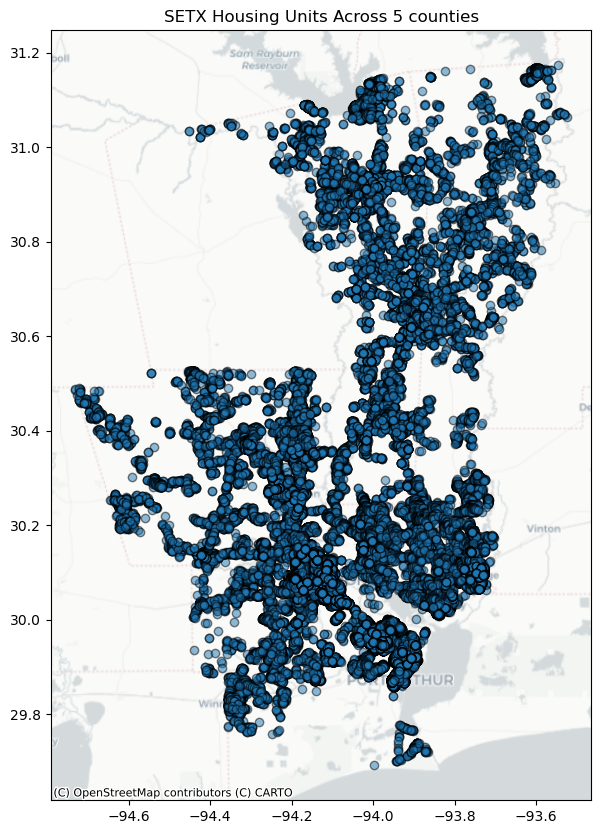

In [15]:
# make a map of points with basemap
ax = hua_gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='k')
ctx.add_basemap(ax, crs=hua_gdf.crs, source=ctx.providers.CartoDB.Positron)
# add title 
ax.set_title("SETX Housing Units Across 5 counties")
plt.show()


<Axes: >

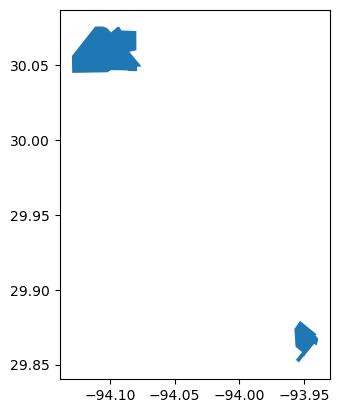

In [16]:
# convert task force site CRS to match hua_gdf
tfsites_gdf = tfsites_gdf.to_crs(hua_gdf.crs)
tfsites_gdf.plot()

In [17]:
# add site id to task force gdf
tfsites_gdf['Site_ID'] = tfsites_gdf.index + 1
tfsites_gdf_v1 = tfsites_gdf[['Site_ID','Site_Name', 'geometry']].copy()

# rename Remove text after - for site name
tfsites_gdf_v1['Site_Name_v2'] = tfsites_gdf_v1['Site_Name'].str.split('-').str[0].str.strip()
# drop original site name
tfsites_gdf_v1 = tfsites_gdf_v1.drop(columns=['Site_Name']) 
# rename Site_Name_v2 to Site_Name
tfsites_gdf_v2 = tfsites_gdf_v1.rename(columns={'Site_Name_v2': 'Site_Name'})
tfsites_gdf_v2.head()

,Site_ID,geometry,Site_Name
0,1,"POLYGON Z ((-93.95327 29.87921 0, -93.94959 29...",West Port Arthur
1,2,"POLYGON Z ((-94.11128 30.07594 0, -94.10533 30...",Southeast Beaumont


### Spatial Join
Add Task Force Site ID to HUA

In [18]:
# spatial join hua_gdf with tfsites_gdf
hua_tfsites_gdf = gpd.sjoin(hua_gdf, tfsites_gdf_v2, how="left", predicate="intersects")
hua_tfsites_gdf.head(1)

,huid,Block2020,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,...,randincome,poverty,placeNAME20,x,y,occtype,geometry,index_right,Site_ID,Site_Name
0,B481990302002008H002,481990302002008,481990302002008,481990302002,48199030200,48199.0,0.0,NaN,NaN,NaN,...,NaN,NaN,Sour Lake,-94.411062,30.139761,COM1,POINT (-94.41106 30.13976),NaN,NaN,NaN


In [19]:
# drop index_right column from hua_tfsites_tract_bg_svi_gdf
hua_tfsites_gdf = hua_tfsites_gdf.drop(columns=['index_right'])

In [20]:
# look for SVIcat = Index Total
svi_datadictionary_df[svi_datadictionary_df['SVIcat'] == 'Index Total']

,SVI,year,newvarname,SVIcat,label,oldvarname
20,CDC,2020,C202090012,Index Total,Overall Percentile Ranking for Texas,RPL_THEMES_TX
44,HRRC,2020,H202090012,Index Total,Statewide Percentile Rank,SVIp
72,UTP,2020,U202090012,Index Total,Factor Analysis Scaled 0 to 1 Normalized Acros...,FA_SVI_Scaled_v2


In [21]:
# Merge tract SVI data with hua_tfsites_gdf
tract_svi_subset = tract_svi_gdf[['TRACT2020','C202090012','H202090012','U202090012']]
# Rename BG columns to avoid conflicts with tract columns
tract_svi_subset = tract_svi_subset.rename(columns={'C202090012':'CDCSVI_TRACT', 'H202090012': 'HRRCSVI_TRACT', 'U202090012': 'SVInsight_TRACT'})

# Merge block group SVI data 
bg_svi_subset = blockgroup_svi_gdf[['BG2020','H202090012','U202090012']]
# Rename BG columns to avoid conflicts with tract columns
bg_svi_subset = bg_svi_subset.rename(columns={'H202090012': 'HRRCSVI_BG', 'U202090012': 'SVInsight_BG'})

In [22]:
# merge tract_site_df with tract_svi_gdf
hua_tfsites_tract_svi_gdf = hua_tfsites_gdf.merge(tract_svi_subset, left_on='tractid', right_on='TRACT2020')
hua_tfsites_tract_svi_gdf.head(1)

,huid,Block2020,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,...,x,y,occtype,geometry,Site_ID,Site_Name,TRACT2020,CDCSVI_TRACT,HRRCSVI_TRACT,SVInsight_TRACT
0,B481990302002008H002,481990302002008,481990302002008,481990302002,48199030200,48199.0,0.0,NaN,NaN,NaN,...,-94.411062,30.139761,COM1,POINT (-94.41106 30.13976),NaN,NaN,48199030200,42.26,49.0,45.744


In [23]:
# merge tract_site_df with tract_svi_gdf
hua_tfsites_tract_bg_svi_gdf = hua_tfsites_tract_svi_gdf.merge(bg_svi_subset, left_on='bgid', right_on='BG2020')
hua_tfsites_tract_bg_svi_gdf.head(1)

,huid,Block2020,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,...,geometry,Site_ID,Site_Name,TRACT2020,CDCSVI_TRACT,HRRCSVI_TRACT,SVInsight_TRACT,BG2020,HRRCSVI_BG,SVInsight_BG
0,B481990302002008H002,481990302002008,481990302002008,481990302002,48199030200,48199.0,0.0,NaN,NaN,NaN,...,POINT (-94.41106 30.13976),NaN,NaN,48199030200,42.26,49.0,45.744,481990302002,74.3,46.351


### Add Air Site ID

In [24]:
# Join 1km grid to HUA data
hua_with_1km_grid = spatial_join_grid_to_hua(
    grid_gdf=grid_1km_gdf, 
    hua_gdf=hua_tfsites_tract_bg_svi_gdf, 
    resolution_name='1km'
)

# Join 4km grid to HUA data with 1km grid data
hua_with_4km_grid = spatial_join_grid_to_hua(
    grid_gdf=grid_4km_gdf,
    hua_gdf=hua_tfsites_tract_bg_svi_gdf, 
    resolution_name='4km'
)

Performing spatial join between 1km grid and HUA data...
Grid shape: (5184, 85)
HUA shape: (192639, 31)
Spatial join complete. Result shape: (192639, 116)
Performing spatial join between 4km grid and HUA data...
Grid shape: (8019, 85)
HUA shape: (192639, 31)
Spatial join complete. Result shape: (192639, 116)


In [25]:
# print all columns in hua_with_1km_grid
for col in hua_with_1km_grid.columns:
    print(col)

huid
Block2020
blockid
bgid
tractid
FIPScounty
numprec
ownershp
race
hispan
family
vacancy
gqtype
incomegroup
hhinc
randincome
poverty
placeNAME20
x
y
occtype
geometry
Site_ID
Site_Name
TRACT2020
CDCSVI_TRACT
HRRCSVI_TRACT
SVInsight_TRACT
BG2020
HRRCSVI_BG
SVInsight_BG
index__1km
air_grid_id_1km
row_idx
col_idx
uifl_1km_Benzene_p75
uifl_1km_Benzene_p100
uifl_1km_Benzene_p95
uifl_1km_Benzene_p50
uifl_1km_Benzene_p25
uifl_1km_Benzene_p98
uifl_1km_Benzene_p90
uifl_1km_Benzene_mean
uifl_1km_Benzene_p99
uifl_1km_Acetonitrile_p90
uifl_1km_Acetonitrile_p98
uifl_1km_Acetonitrile_mean
uifl_1km_Acetonitrile_p50
uifl_1km_Acetonitrile_p75
uifl_1km_Acetonitrile_p99
uifl_1km_Acetonitrile_p25
uifl_1km_Acetonitrile_p95
uifl_1km_Acetonitrile_p100
uifl_1km_1,3-Butadiene_p100
uifl_1km_1,3-Butadiene_p90
uifl_1km_1,3-Butadiene_p98
uifl_1km_1,3-Butadiene_p95
uifl_1km_1,3-Butadiene_p75
uifl_1km_1,3-Butadiene_mean
uifl_1km_1,3-Butadiene_p50
uifl_1km_1,3-Butadiene_p25
uifl_1km_1,3-Butadiene_p99
uifl_1km_Styren

In [26]:
# reorder columns
key_column_order = ['huid', 'tractid', 'bgid', 'air_grid_id_1km','Site_ID','Site_Name']
# move key columns to front of df
remaining_cols = [col for col in hua_with_1km_grid.columns if col not in key_column_order]
hua_with_1km_grid = hua_with_1km_grid[key_column_order + remaining_cols]

# reorder columns
key_column_order = ['huid', 'tractid', 'bgid', 'air_grid_id_4km','Site_ID','Site_Name']
# move key columns to front of df
remaining_cols = [col for col in hua_with_4km_grid.columns if col not in key_column_order]
hua_with_4km_grid = hua_with_4km_grid[key_column_order + remaining_cols]

In [27]:
# describe ids
hua_with_1km_grid[['huid', 'tractid', 'bgid', 'air_grid_id_1km']].describe()

,huid,tractid,bgid,air_grid_id_1km
count,192639,192639,192639,147237
unique,192639,128,367,1464
top,B481990302002008H002,48199030302,482419501011,airuifl_1km_0016_0021
freq,1,3180,1700,1287


In [28]:
# drop observations with missing 1km grid id
hua_with_1km_grid = hua_with_1km_grid.dropna(subset=['air_grid_id_1km'])
hua_with_1km_grid[['huid', 'tractid', 'bgid', 'air_grid_id_1km']].describe()

,huid,tractid,bgid,air_grid_id_1km
count,147237,147237,147237,147237
unique,147237,104,294,1464
top,B481990306001005H015,48245000310,482450001012,airuifl_1km_0016_0021
freq,1,2749,1492,1287


# Step 3: Explore Data

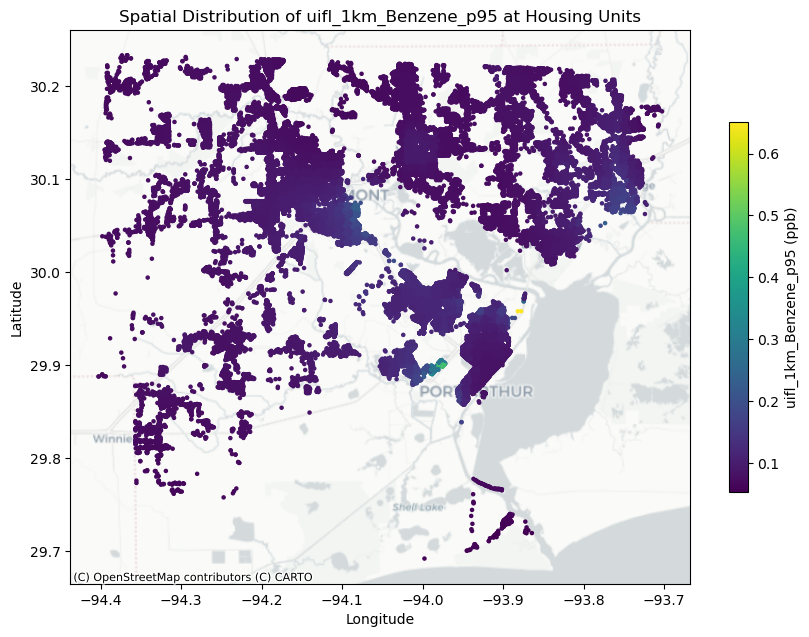

In [29]:
pollutant = "uifl_1km_Benzene_p95"
# map hua point data with air pollution values
fig, ax = plt.subplots(figsize=(10, 8))
hua_with_1km_grid.plot(column=f'{pollutant}', ax=ax, legend=True,
                 cmap='viridis', markersize=5,
                 legend_kwds={'label': f'{pollutant} (ppb)', 'shrink': 0.6})
ctx.add_basemap(ax, crs=hua_with_1km_grid.crs, source=ctx.providers.CartoDB.Positron)
plt.title(f"Spatial Distribution of {pollutant} at Housing Units")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

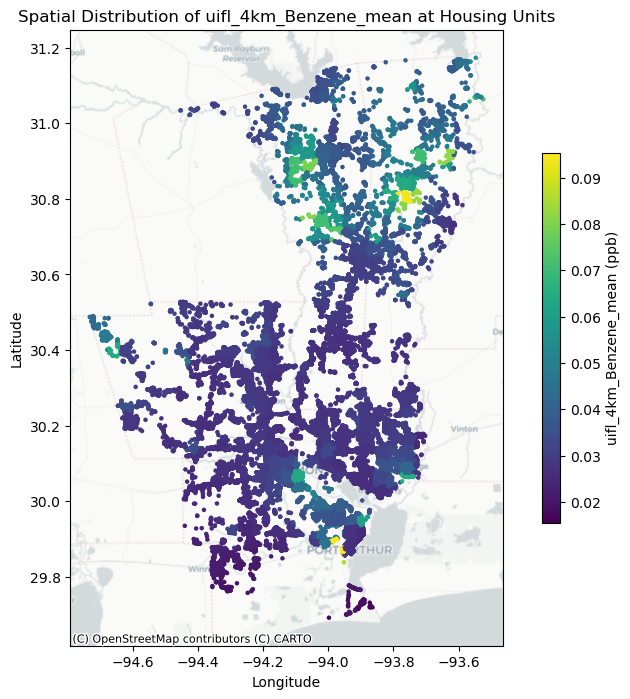

In [30]:
pollutant = "uifl_4km_Benzene_mean"
# map hua point data with air pollution values
fig, ax = plt.subplots(figsize=(10, 8))
hua_with_4km_grid.plot(column=f'{pollutant}', ax=ax, legend=True,
                 cmap='viridis', markersize=5,
                 legend_kwds={'label': f'{pollutant} (ppb)', 'shrink': 0.6})
ctx.add_basemap(ax, crs=hua_with_4km_grid.crs, source=ctx.providers.CartoDB.Positron)
plt.title(f"Spatial Distribution of {pollutant} at Housing Units")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Save results

In [31]:
# save hua_with_grid as CSV and GeoPackage
output_csv_path = os.path.join(programname, f"{programname}_1km.csv")
output_gpkg_path = os.path.join(programname, f"{programname}_1km.gpkg")
hua_with_1km_grid.to_file(output_gpkg_path, driver="GPKG")
hua_with_1km_grid.to_csv(output_csv_path)

output_csv_path = os.path.join(programname, f"{programname}_4km.csv")
output_gpkg_path = os.path.join(programname, f"{programname}_4km.gpkg")
hua_with_4km_grid.to_file(output_gpkg_path, driver="GPKG")
hua_with_4km_grid.to_csv(output_csv_path)